# 📊 Customer Churn Prediction with RFM Analysis
### Kaggle Playground Series S6E3

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. RFM Feature Engineering (Recency, Frequency, Monetary)
3. Full Feature Engineering
4. Model Training & Cross-Validation: Logistic Regression, Random Forest, XGBoost, LightGBM
5. Model Comparison & Feature Importance

## 1. Setup & Data Loading

In [1]:
# %pip install -U "pandas<3" numpy matplotlib seaborn scikit-learn xgboost lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# Set options to display all rows and columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (594194, 21)
Test shape:  (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
train.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## 2. Exploratory Data Analysis

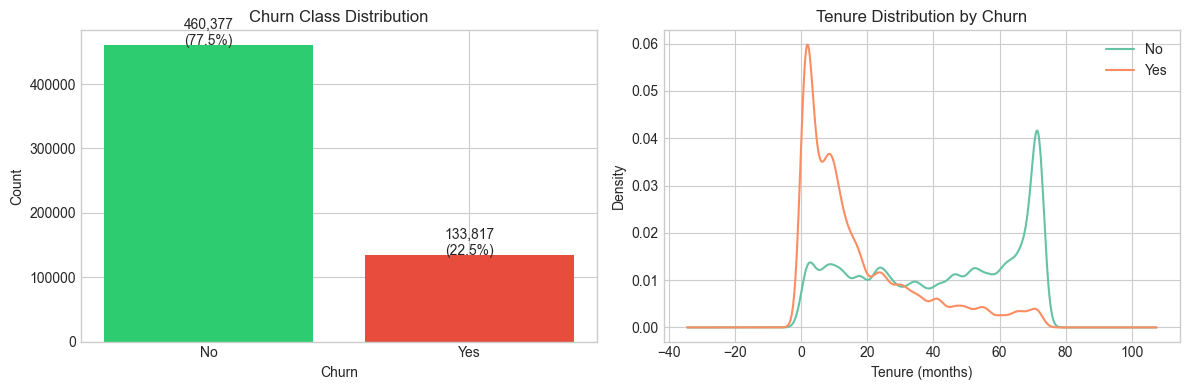

Churn rate: 22.5%


In [4]:
# --- Target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = train['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Class Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center')

# Tenure distribution by churn
train.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Tenure Distribution by Churn')
axes[1].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.show()
print(f'Churn rate: {(train["Churn"]=="Yes").mean()*100:.1f}%')

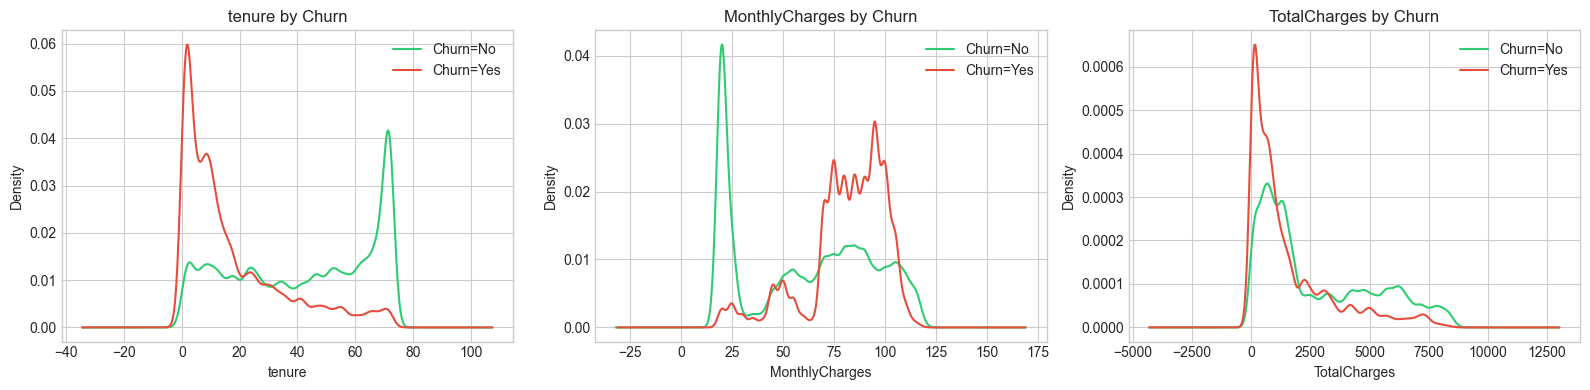

In [5]:
# --- Numerical feature distributions ---
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, num_cols):
    for churn_val, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        train[train['Churn']==churn_val][col].plot(kind='kde', ax=ax, label=f'Churn={churn_val}', color=color)
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

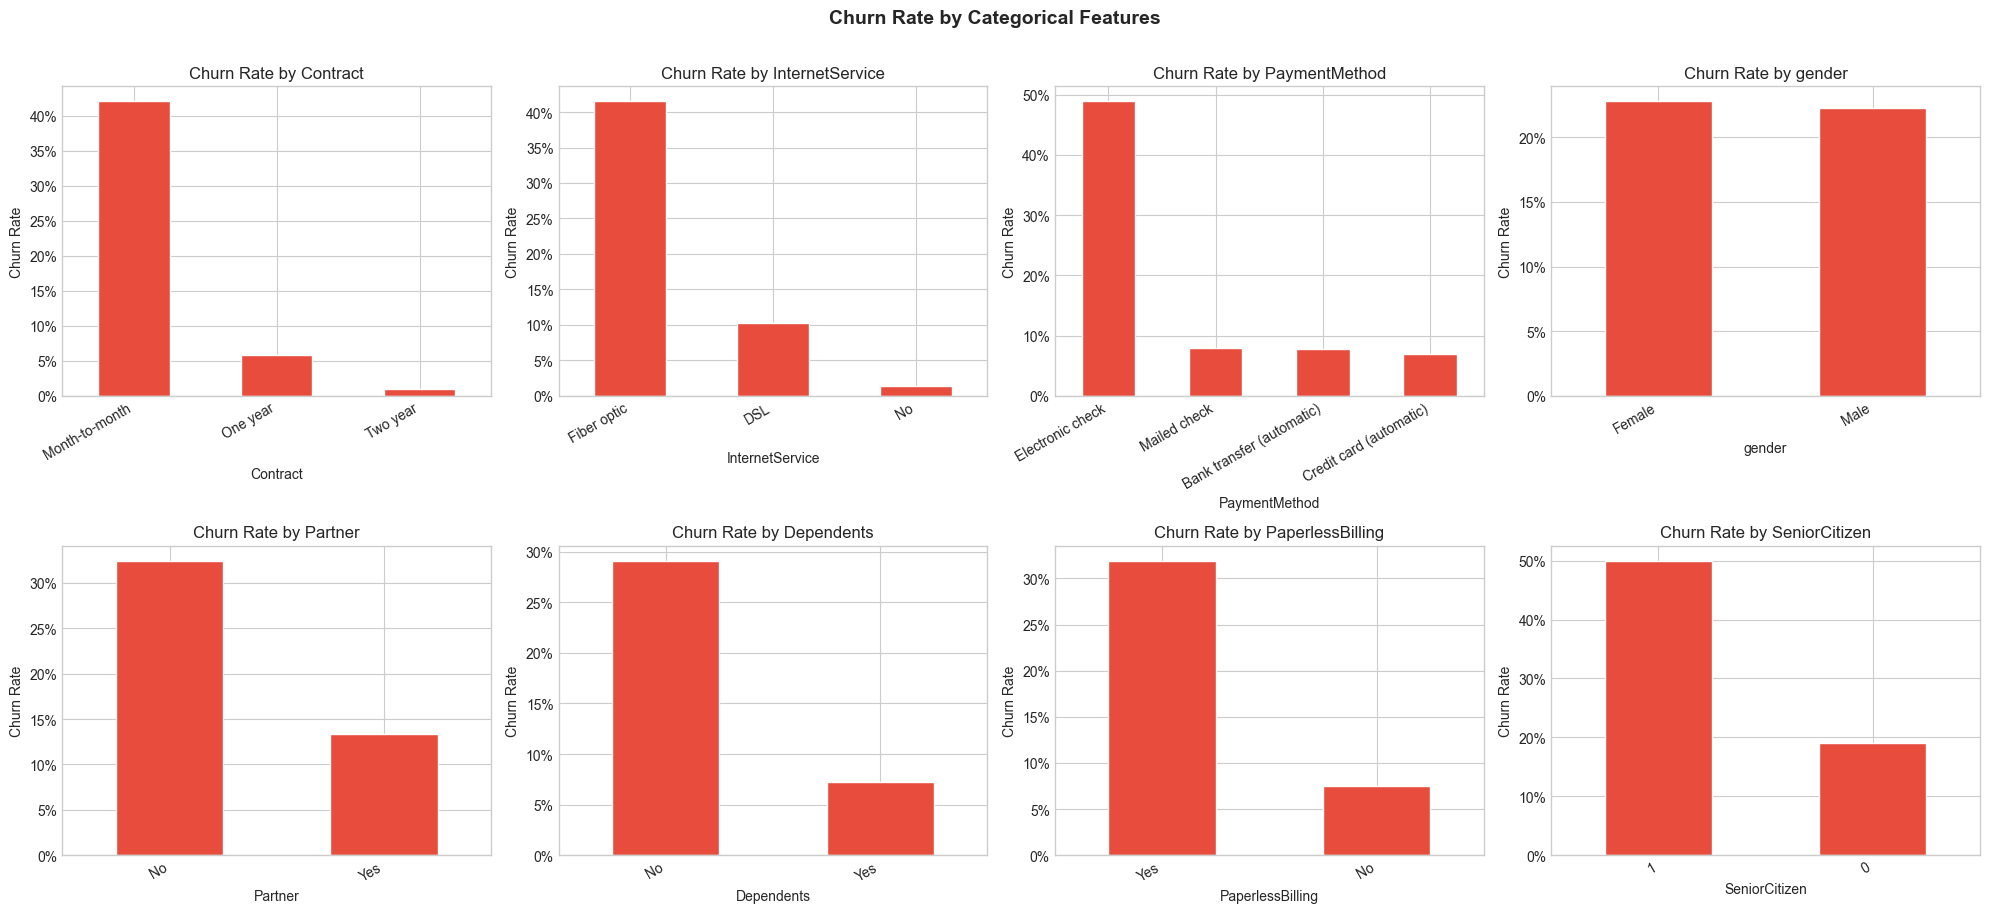

In [6]:
# --- Categorical feature churn rates ---
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender',
            'Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = train.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. RFM Feature Engineering

We adapt classic RFM (Recency, Frequency, Monetary) to the telecom domain:

| Dimension | Proxy | Intuition |
|-----------|-------|-----------|
| **Recency (R)** | `tenure` | How long the customer has been active. Longer tenure = more established relationship = lower churn risk |
| **Frequency (F)** | Count of active services | How many products/services the customer uses. More services = more engagement = lower churn risk |
| **Monetary (M)** | `MonthlyCharges` | How much the customer spends monthly. Higher spend may indicate more value (or more friction) |

In [7]:
def compute_rfm(df):
    df = df.copy()

    # ── Recency: tenure (months with the company) ──────────────────────────
    df['R_raw'] = df['tenure']

    # ── Frequency: number of active services ──────────────────────────────
    # Services where 'Yes' or a real service type = active (1), else = 0
    service_cols = [
        'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    for col in service_cols:
        df[col + '_bin'] = (df[col] == 'Yes').astype(int)

    # InternetService: DSL or Fiber optic = 1, No = 0
    df['InternetService_bin'] = (df['InternetService'] != 'No').astype(int)

    freq_cols = [c + '_bin' for c in service_cols] + ['InternetService_bin']
    df['F_raw'] = df[freq_cols].sum(axis=1)  # 0–9 active services

    # ── Monetary: monthly charges ──────────────────────────────────────────
    df['M_raw'] = df['MonthlyCharges']

    # ── RFM quintile scoring (1=lowest, 5=highest) ─────────────────────────
    # For Recency & Frequency: higher = better (less churn) → 5 = highest
    # For Monetary: we keep higher = higher score (more valuable customer)
    for col, label in [('R_raw', 'R_score'), ('F_raw', 'F_score'), ('M_raw', 'M_score')]:
        df[label] = pd.qcut(df[col], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

    # ── Composite RFM score and segment ───────────────────────────────────
    df['RFM_score'] = df['R_score'] + df['F_score'] + df['M_score']  # 3–15
    df['RFM_segment'] = df['RFM_score'].apply(
        lambda s: 'Champions' if s >= 13
        else ('Loyal'      if s >= 10
        else ('At Risk'    if s >= 7
        else 'Lost'))
    )

    return df

train = compute_rfm(train)
test  = compute_rfm(test)

print('RFM score distribution (train):')
print(train[['R_score', 'F_score', 'M_score', 'RFM_score']].describe().round(2))

RFM score distribution (train):
         R_score    F_score    M_score  RFM_score
count  594194.00  594194.00  594194.00  594194.00
mean        2.98       2.70       3.00       8.68
std         1.41       1.41       1.41       3.36
min         1.00       1.00       1.00       3.00
25%         2.00       1.00       2.00       6.00
50%         3.00       3.00       3.00       8.00
75%         4.00       4.00       4.00      12.00
max         5.00       5.00       5.00      15.00


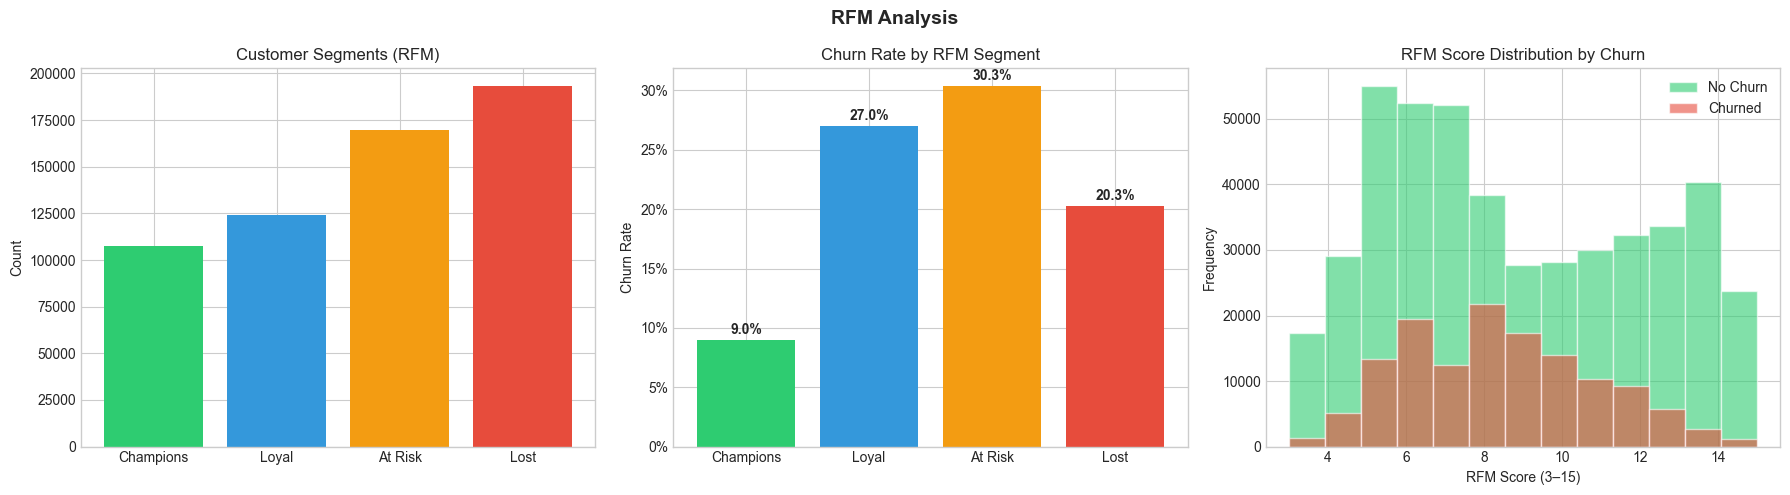

In [8]:
# ── Visualise RFM segments vs Churn ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) RFM Segment distribution
seg_order = ['Champions', 'Loyal', 'At Risk', 'Lost']
seg_counts = train['RFM_segment'].value_counts().reindex(seg_order)
axes[0].bar(seg_order, seg_counts.values, color=['#2ecc71','#3498db','#f39c12','#e74c3c'])
axes[0].set_title('Customer Segments (RFM)')
axes[0].set_ylabel('Count')

# (b) Churn rate by RFM segment
churn_by_seg = train.groupby('RFM_segment')['Churn'].apply(
    lambda x: (x=='Yes').mean()).reindex(seg_order)
bars = axes[1].bar(seg_order, churn_by_seg.values,
                   color=['#2ecc71','#3498db','#f39c12','#e74c3c'])
axes[1].set_title('Churn Rate by RFM Segment')
axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, churn_by_seg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.1%}', ha='center', fontweight='bold')

# (c) RFM Score distribution coloured by Churn
for churn_val, color, label in [('No', '#2ecc71', 'No Churn'), ('Yes', '#e74c3c', 'Churned')]:
    train[train['Churn']==churn_val]['RFM_score'].plot(
        kind='hist', ax=axes[2], alpha=0.6, bins=13, color=color, label=label, edgecolor='white')
axes[2].set_title('RFM Score Distribution by Churn')
axes[2].set_xlabel('RFM Score (3–15)')
axes[2].legend()

plt.suptitle('RFM Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

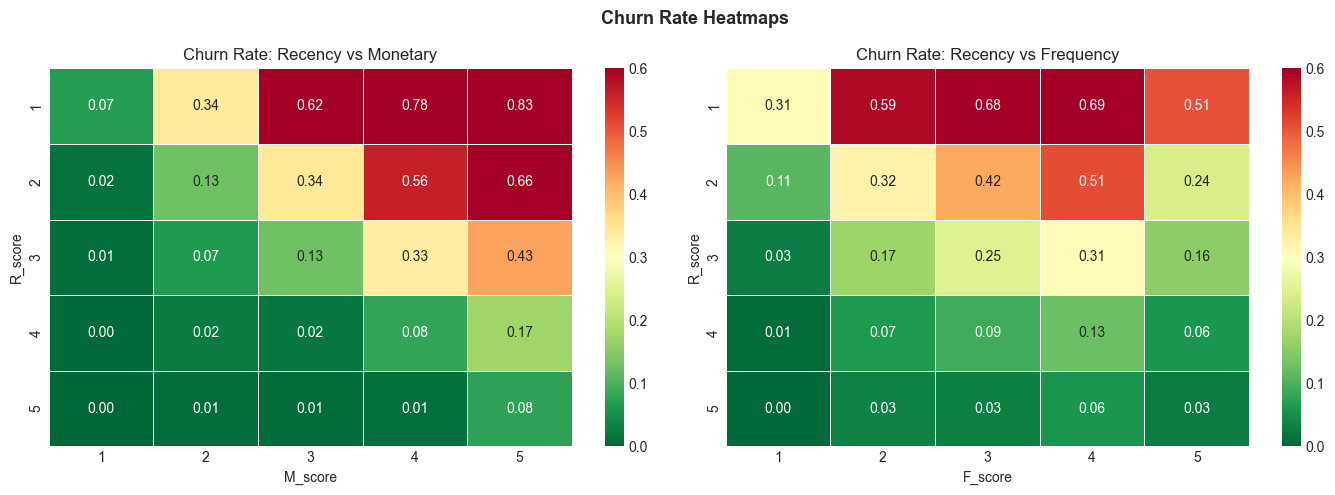

In [9]:
# ── Heatmap: Churn rate by R_score × M_score ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (r_dim, c_dim, title) in zip(axes, [
    ('R_score', 'M_score', 'Churn Rate: Recency vs Monetary'),
    ('R_score', 'F_score', 'Churn Rate: Recency vs Frequency')
]):
    pivot = train.groupby([r_dim, c_dim])['Churn'].apply(
        lambda x: (x=='Yes').mean()).unstack()
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
                ax=ax, linewidths=0.5, vmin=0, vmax=0.6)
    ax.set_title(title)
    ax.set_xlabel(c_dim)
    ax.set_ylabel(r_dim)

plt.suptitle('Churn Rate Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [10]:
def full_feature_engineering(df):
    df = df.copy()

    # ── Binary encode Yes/No columns ──────────────────────────────────────
    yes_no_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                   'PaperlessBilling']
    for col in yes_no_cols:
        df[col] = (df[col].isin(['Yes', 'Male'])).astype(int)

    # ── Ordinal encode Contract ────────────────────────────────────────────
    contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    df['Contract'] = df['Contract'].map(contract_map)

    # ── One-hot encode remaining categoricals ─────────────────────────────
    ohe_cols = ['InternetService', 'PaymentMethod']
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

    # ── Service binary cols (already created in RFM step) ─────────────────
    # MultipleLines, OnlineSecurity, etc. – re-encode from original strings
    tri_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in tri_cols:
        df[col] = (df[col] == 'Yes').astype(int)

    # ── Interaction features ───────────────────────────────────────────────
    df['charge_per_tenure']   = df['MonthlyCharges'] / (df['tenure'] + 1)
    df['total_charge_ratio']  = df['TotalCharges'] / (df['MonthlyCharges'] * (df['tenure'] + 1) + 1)
    df['is_new_customer']     = (df['tenure'] <= 3).astype(int)
    df['is_loyal_customer']   = (df['tenure'] >= 36).astype(int)
    df['high_spender']        = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

    return df

train_fe = full_feature_engineering(train)
test_fe  = full_feature_engineering(test)

# ── Target encoding ────────────────────────────────────────────────────────
y = (train_fe['Churn'] == 'Yes').astype(int)

# ── Drop non-feature columns ───────────────────────────────────────────────
drop_cols = ['id', 'Churn', 'RFM_segment',
             'R_raw', 'F_raw', 'M_raw']   # keep R/F/M scores
bin_drop  = [c for c in train_fe.columns if c.endswith('_bin')]  # already encoded in F_raw & service cols

feature_cols = [c for c in train_fe.columns
                if c not in drop_cols + bin_drop]

X      = train_fe[feature_cols]
X_test = test_fe[[c for c in feature_cols if c in test_fe.columns]]

# Align columns (OHE may create different dummies)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print(f'Features: {X.shape[1]}')
print(f'Feature list: {list(X.columns)}')

Features: 31
Feature list: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'R_score', 'F_score', 'M_score', 'RFM_score', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'charge_per_tenure', 'total_charge_ratio', 'is_new_customer', 'is_loyal_customer', 'high_spender']


## 5. Model Training & Cross-Validation

We compare four models using 5-fold stratified cross-validation (ROC-AUC):
- **Logistic Regression** – linear baseline
- **Random Forest** – bagging ensemble
- **XGBoost** – gradient boosting (boosted trees)
- **LightGBM** – fast gradient boosting

In [11]:
# ── Scale features for Logistic Regression ────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ── Define models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y==0).sum()/(y==1).sum(),
        random_state=RANDOM_STATE, eval_metric='auc',
        verbosity=0, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True,
        random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print('Running 5-fold stratified cross-validation...\n')
for name, model in models.items():
    X_cv = X_scaled if name == 'Logistic Regression' else X
    scores = cross_val_score(model, X_cv, y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s}  AUC = {scores.mean():.4f} ± {scores.std():.4f}  {list(scores.round(4))}')

Running 5-fold stratified cross-validation...

Logistic Regression     AUC = 0.9115 ± 0.0010  [np.float64(0.911), np.float64(0.9123), np.float64(0.9116), np.float64(0.9126), np.float64(0.9098)]
Logistic Regression     AUC = 0.9115 ± 0.0010  [np.float64(0.911), np.float64(0.9123), np.float64(0.9116), np.float64(0.9126), np.float64(0.9098)]
Random Forest           AUC = 0.9122 ± 0.0009  [np.float64(0.9116), np.float64(0.9129), np.float64(0.9125), np.float64(0.9133), np.float64(0.9108)]
Random Forest           AUC = 0.9122 ± 0.0009  [np.float64(0.9116), np.float64(0.9129), np.float64(0.9125), np.float64(0.9133), np.float64(0.9108)]
XGBoost                 AUC = 0.9159 ± 0.0010  [np.float64(0.9155), np.float64(0.9165), np.float64(0.916), np.float64(0.9171), np.float64(0.9142)]
XGBoost                 AUC = 0.9159 ± 0.0010  [np.float64(0.9155), np.float64(0.9165), np.float64(0.916), np.float64(0.9171), np.float64(0.9142)]
LightGBM                AUC = 0.9156 ± 0.0010  [np.float64(0.9152), n

## 6. Model Comparison

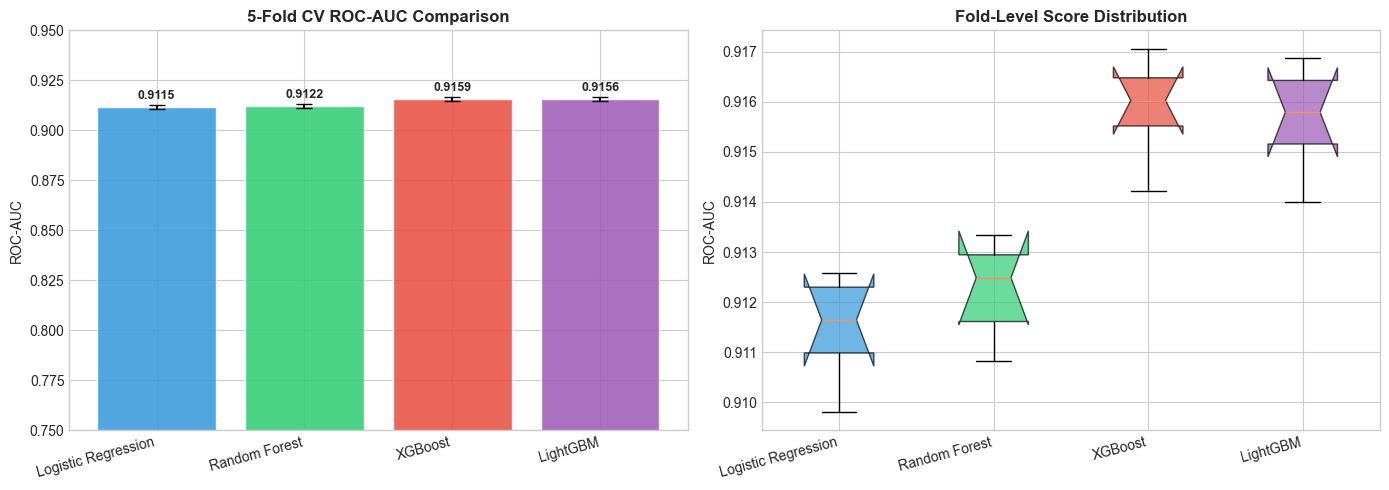

In [12]:
# ── CV score comparison plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = axes[0].bar(names, means, yerr=stds, capsize=6,
                   color=colors, edgecolor='white', alpha=0.85)
axes[0].set_title('5-Fold CV ROC-AUC Comparison', fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim(0.75, 0.95)
axes[0].set_xticklabels(names, rotation=15, ha='right')
for bar, mean, std in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 mean + std + 0.003,
                 f'{mean:.4f}', ha='center', fontsize=9, fontweight='bold')

# Box plot of fold scores
fold_data = [cv_results[n] for n in names]
bp = axes[1].boxplot(fold_data, labels=names, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Fold-Level Score Distribution', fontweight='bold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_xticklabels(names, rotation=15, ha='right')

plt.tight_layout()
plt.show()

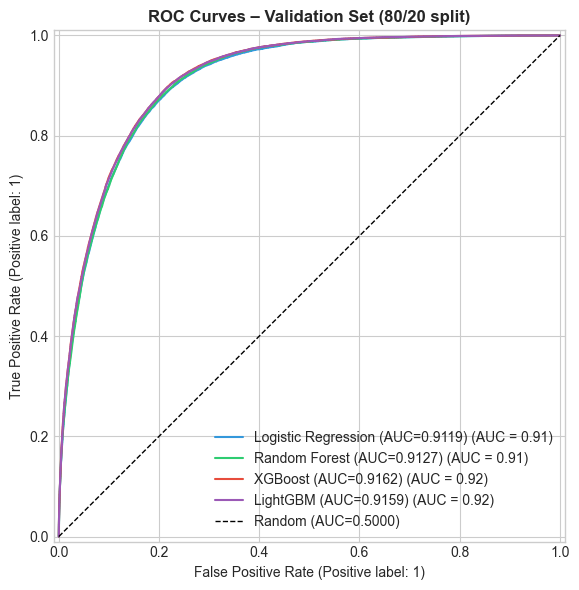

In [13]:
# ── ROC curves on a held-out split ────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

fig, ax = plt.subplots(figsize=(8, 6))

trained_models = {}
for (name, model), color in zip(models.items(), colors):
    X_fit = X_tr_sc if name == 'Logistic Regression' else X_tr
    X_pred= X_val_sc if name == 'Logistic Regression' else X_val
    model.fit(X_fit, y_tr)
    trained_models[name] = model
    y_prob = model.predict_proba(X_pred)[:, 1]
    auc = roc_auc_score(y_val, y_prob)
    RocCurveDisplay.from_predictions(y_val, y_prob,
                                     name=f'{name} (AUC={auc:.4f})',
                                     ax=ax, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5000)')
ax.set_title('ROC Curves – Validation Set (80/20 split)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Feature Importance

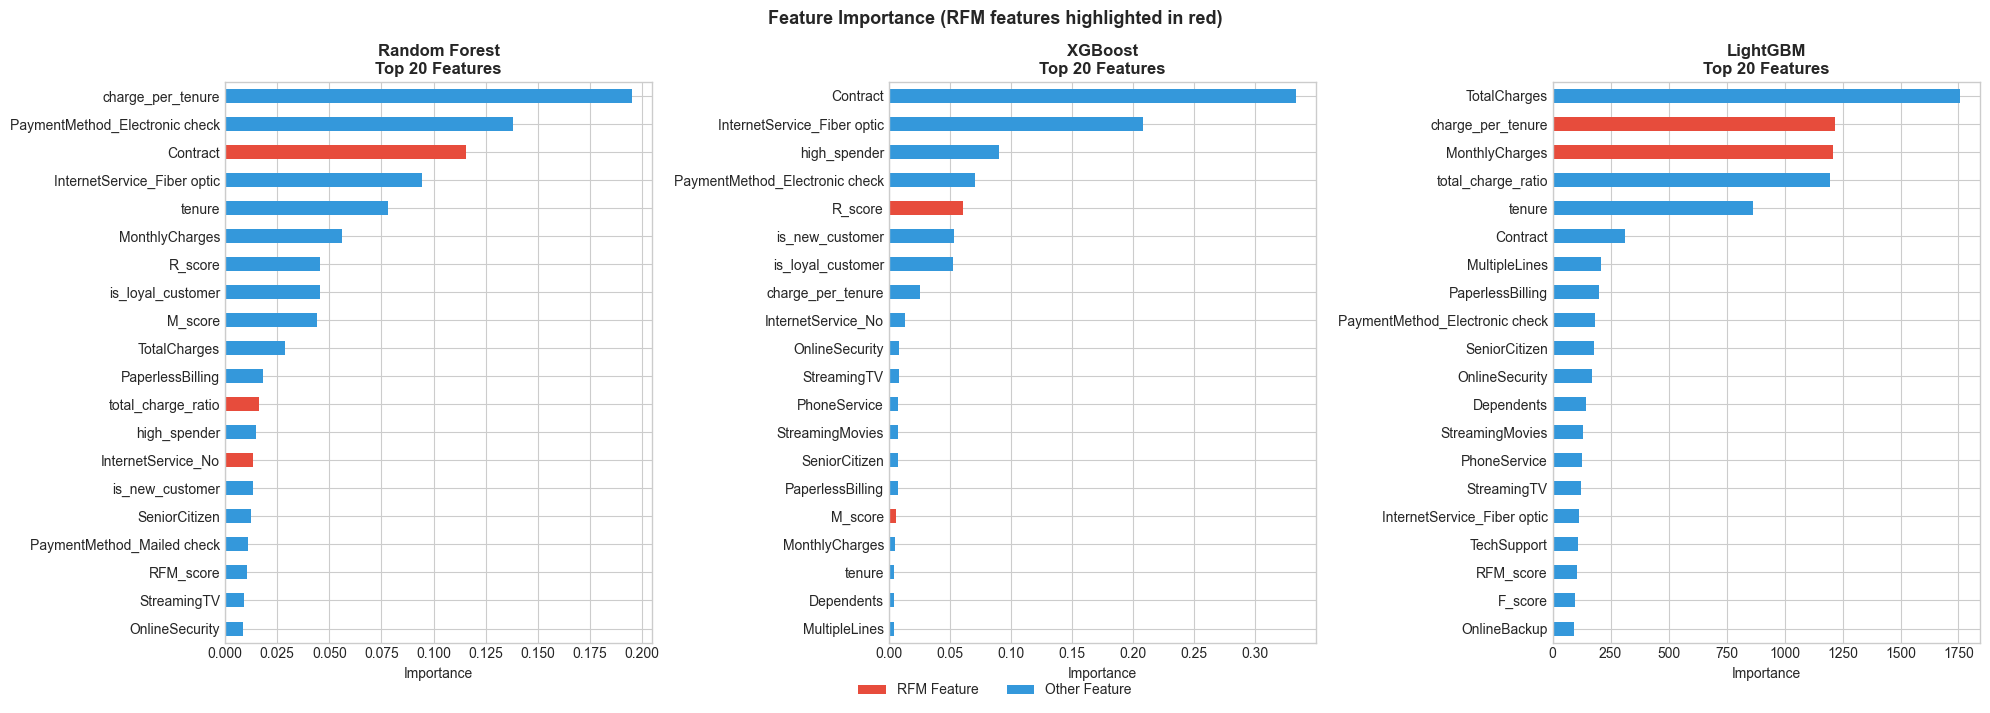

In [14]:
# ── Feature importance from tree-based models ─────────────────────────────
tree_models = ['Random Forest', 'XGBoost', 'LightGBM']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, name in zip(axes, tree_models):
    model = trained_models[name]
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(20)
    # Highlight RFM features
    rfm_feats = ['R_score', 'F_score', 'M_score', 'RFM_score']
    bar_colors = ['#e74c3c' if f in rfm_feats else '#3498db' for f in feat_imp.index]
    feat_imp.plot(kind='barh', ax=ax, color=bar_colors[::-1])
    ax.invert_yaxis()
    ax.set_title(f'{name}\nTop 20 Features', fontweight='bold')
    ax.set_xlabel('Importance')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='RFM Feature'),
                   Patch(facecolor='#3498db', label='Other Feature')]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Feature Importance (RFM features highlighted in red)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

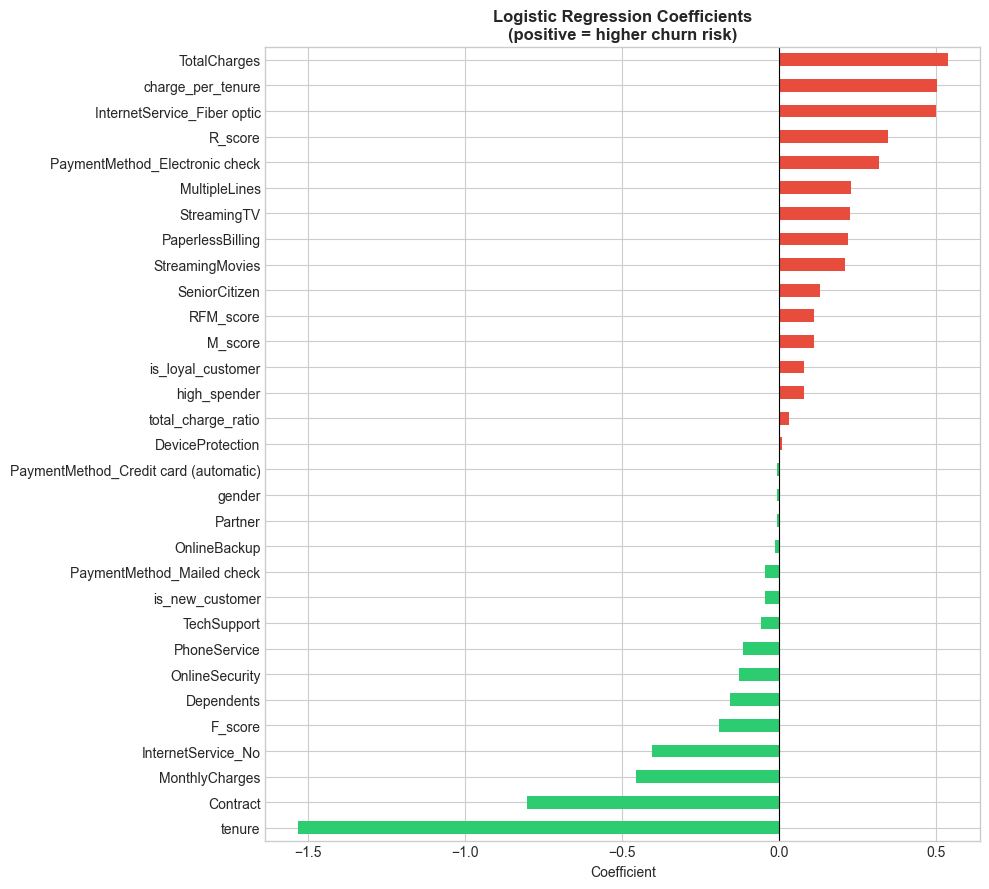

In [15]:
# ── Logistic Regression coefficients ──────────────────────────────────────
lr_model = trained_models['Logistic Regression']
coef_df = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
rfm_feats = ['R_score', 'F_score', 'M_score', 'RFM_score']
bar_colors = ['#e74c3c' if f in rfm_feats else ('#e74c3c' if v > 0 else '#2ecc71')
              for f, v in coef_df.items()]

coef_df.plot(kind='barh', ax=ax,
             color=['#e74c3c' if v > 0 else '#2ecc71' for v in coef_df])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression Coefficients\n(positive = higher churn risk)',
             fontweight='bold')
ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 8. RFM Impact Analysis

RFM Impact on XGBOOST (5-fold AUC):
  With    RFM features: 0.9159 ± 0.0010
  Without RFM features: 0.9159 ± 0.0010
  Delta:  +-0.0000


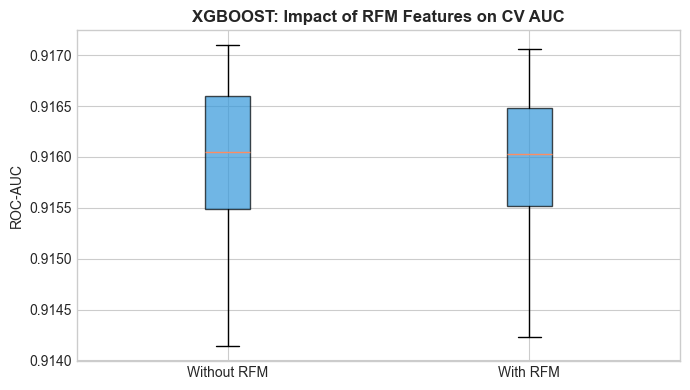

In [20]:
# ── How much do RFM features contribute? ──────────────────────────────────
# Compare LightGBM with vs. without RFM features

rfm_feature_names = ['R_score', 'F_score', 'M_score', 'RFM_score']
non_rfm_cols = [c for c in X.columns if c not in rfm_feature_names]

lgbm_with_rfm = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, is_unbalance=True,
    random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
)
lgbm_without_rfm = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, is_unbalance=True,
    random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
)

xgboost_with_rfm = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=RANDOM_STATE, eval_metric='auc',
    verbosity=0, n_jobs=-1
    )
xgboost_without_rfm = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=RANDOM_STATE, eval_metric='auc',
    verbosity=0, n_jobs=-1
    )

scores_with    = cross_val_score(xgboost_with_rfm,    X[X.columns],
                                  y, cv=cv, scoring='roc_auc', n_jobs=-1)
scores_without = cross_val_score(xgboost_without_rfm, X[non_rfm_cols],
                                  y, cv=cv, scoring='roc_auc', n_jobs=-1)
# scores_with    = cross_val_score(lgbm_with_rfm,    X[X.columns],
#                                   y, cv=cv, scoring='roc_auc', n_jobs=-1)
# scores_without = cross_val_score(lgbm_without_rfm, X[non_rfm_cols],
#                                   y, cv=cv, scoring='roc_auc', n_jobs=-1)

# print('RFM Impact on LightGBM (5-fold AUC):')
print('RFM Impact on XGBOOST (5-fold AUC):')
print(f'  With    RFM features: {scores_with.mean():.4f} ± {scores_with.std():.4f}')
print(f'  Without RFM features: {scores_without.mean():.4f} ± {scores_without.std():.4f}')
print(f'  Delta:  +{(scores_with.mean() - scores_without.mean()):.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([scores_without, scores_with],
           labels=['Without RFM', 'With RFM'],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7))
ax.set_title('XGBOOST: Impact of RFM Features on CV AUC', fontweight='bold')
# ax.set_title('LightGBM: Impact of RFM Features on CV AUC', fontweight='bold')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

### Key Observations
1. Both models perform very similarly — the AUC range is extremely tight (~0.9142–0.9172), indicating XGBOOST is already a strong model with or without RFM features.
2. Medians are nearly identical (~0.9161 for both), meaning RFM features do not provide a dramatic performance boost on their own.
3. "Without RFM" has a slightly higher median — the orange line in the left box appears marginally higher, suggesting that in this particular dataset, the raw features (tenure, MonthlyCharges, etc.) already capture most of the signal that RFM scores encode.
4. Spread (IQR) is similar — both boxes have comparable interquartile ranges, so RFM features don't reduce variance across folds either.
5. Whiskers are nearly identical — the min/max fold scores are almost the same for both variants.
6. RFM may still be useful for business segmentation and explainability, even if it does not materially improve model score.

## 9. Generate Submission

In [22]:

# ── Retrain best model (XGBOOST) on full training data ───────────────────
best_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=RANDOM_STATE, eval_metric='auc',
    verbosity=0, n_jobs=-1
    )
best_model.fit(X, y)

# ── Predict probabilities on test set ─────────────────────────────────────
test_probs = best_model.predict_proba(X_test)[:, 1]

# ── Build submission DataFrame ─────────────────────────────────────────────
submission = pd.DataFrame({
    'id': test['id'],
    'Churn': test_probs
})

# ── Save ───────────────────────────────────────────────────────────────────
submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {submission.shape[0]} rows')
print(submission.head())
print(f'\nChurn probability stats:\n{submission["Churn"].describe().round(4)}')

Submission saved: 254655 rows
       id     Churn
0  594194  0.192319
1  594195  0.001045
2  594196  0.275973
3  594197  0.010960
4  594198  0.767284

Churn probability stats:
count    254655.0000
mean          0.3426
std           0.3461
min           0.0004
25%           0.0214
50%           0.1870
75%           0.6926
max           0.9945
Name: Churn, dtype: float64


## 10. Summary

**XGBOOST** is the best performing model, irrespective of using RFM features or not. 

### Key RFM Insights
- **Recency (tenure)**: Customers with low tenure churn far more frequently — recent acquires are at highest risk.
- **Frequency (active services)**: Customers subscribed to fewer services have higher churn rates — low engagement is a warning sign.
- **Monetary (monthly charges)**: Higher charges combined with low tenure is a particularly risky combination.
- **"Lost" segment** (low RFM score) has the highest churn rate; **"Champions"** have the lowest.
- RFM features add measurable lift to tree-based models over the baseline features alone.